# Blunder prediction model arena

This notebook extends the working pawn-loss blunder-prediction pipeline into a
larger model comparison.

It trains and compares:

1. **XGBoost**
2. **LightGBM**
3. **PyTorch MLP**
4. **Advanced PyTorch FT-Transformer-style tabular model**

For each model family, the notebook attempts to produce:

- baseline metrics
- optimized metrics
- confusion matrix
- ROC curve
- precision-recall curve
- threshold scan
- permutation importance
- summary comparison plots

The task is:

> Given the current state of a game, predict whether the player to move will
> make a blunder within their next few own moves.

This version assumes engine evaluations are in **pawn units**, not centipawns.


## 0. Dependency notes

This notebook uses optional libraries. Add them with `uv` from the project root:

```bash
uv add xgboost lightgbm torch optuna
```

If you want SHAP later:

```bash
uv add shap
```

This notebook does **not** require SHAP. It uses permutation importance for a
consistent comparison across all models.


## 1. Main controls

These are the main knobs.

The defaults are intentionally ambitious but still reasonable for a strong
project run:

```python
N_GAMES_SAMPLE = 100_000
BLUNDER_PAWN_LOSS = 2.0
```

For debugging, reduce to:

```python
N_GAMES_SAMPLE = 5_000
OPTUNA_TRIALS = 3
NN_MAX_EPOCHS = 5
```


In [1]:
from pathlib import Path
import importlib.util
import json
import math
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
  ConfusionMatrixDisplay,
  PrecisionRecallDisplay,
  RocCurveDisplay,
  average_precision_score,
  balanced_accuracy_score,
  classification_report,
  confusion_matrix,
  f1_score,
  precision_recall_curve,
  roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Main data size control.
N_GAMES_SAMPLE = 5_000
RANDOM_GAME_SAMPLE = True

# Pawn-loss blunder definition.
MISTAKE_PAWN_LOSS = 1.0
BLUNDER_PAWN_LOSS = 2.0

# Predict blunder within this many own moves.
HORIZON_OWN_MOVES = 5

# Clip huge evals, e.g. possible mate encodings.
MAX_ABS_EVAL_PAWNS = 50.0

# Hyperparameter optimization controls.
RUN_HYPERPARAM_OPT = True
OPTUNA_TRIALS = 3  #15
OPTUNA_TIMEOUT_SECONDS = None

# Neural-network controls.
NN_TRAIN_MAX_ROWS = 50_000 #300_000
NN_VALID_INTERNAL_MAX_ROWS = 75_000

NN_MAX_EPOCHS = 3 #8 #20
NN_BATCH_SIZE = 4096
NN_PATIENCE = 4
NN_LEARNING_RATE = 1e-3

NN_PROGRESS_EVERY_N_BATCHES = 25

# Permutation importance controls.
RUN_PERMUTATION_IMPORTANCE = True
PERM_IMPORTANCE_MAX_ROWS = 5_000 #25_000
PERM_IMPORTANCE_REPEATS = 3

# Plot controls.
MAX_MODELS_IN_CONFUSION_GRID = 10

pd.set_option("display.max_columns", 150)


## 2. Optional dependency checks


In [2]:
def has_package(name):
  return importlib.util.find_spec(name) is not None


HAS_XGBOOST = has_package("xgboost")
HAS_LIGHTGBM = has_package("lightgbm")
HAS_TORCH = has_package("torch")
HAS_OPTUNA = has_package("optuna")

print("Optional package availability")
print("xgboost :", HAS_XGBOOST)
print("lightgbm:", HAS_LIGHTGBM)
print("torch   :", HAS_TORCH)
print("optuna  :", HAS_OPTUNA)

if not HAS_XGBOOST:
  print("Missing xgboost. Install with: uv add xgboost")

if not HAS_LIGHTGBM:
  print("Missing lightgbm. Install with: uv add lightgbm")

if not HAS_TORCH:
  print("Missing torch. Install with: uv add torch")

if not HAS_OPTUNA:
  print("Missing optuna. Hyperparameter optimization will be skipped.")
  print("Install with: uv add optuna")


Optional package availability
xgboost : True
lightgbm: True
torch   : True
optuna  : True


## 3. Locate project root and load data


In [3]:
def find_project_root(start=None):
  if start is None:
    start = Path.cwd()

  start = Path(start).resolve()

  for path in [start, *start.parents]:
    has_pyproject = (path / "pyproject.toml").exists()
    has_data = (path / "data").exists()

    if has_pyproject and has_data:
      return path

  raise FileNotFoundError(
    "Could not find project root. Run from the project root "
    "or from a subdirectory such as scratch/."
  )


ROOT = find_project_root()
DATA_DIR = ROOT / "data" / "processed" / "lichess-2017-05-eval-all"

GAMES_PATH = DATA_DIR / "games.parquet"
PLIES_PATH = DATA_DIR / "plies.parquet"
FEATURES_PATH = DATA_DIR / "features.parquet"
DICT_PATH = DATA_DIR / "feature_dictionary.csv"

print(f"Project root: {ROOT}")
print(f"Data dir:     {DATA_DIR}")

for path in [GAMES_PATH, PLIES_PATH, FEATURES_PATH, DICT_PATH]:
  print(f"{path.name:24s} exists={path.exists()}")


Project root: /Users/asudler/Desktop/ucph/coursework/2526-block4/aml/final-project/root/workspace/aidan_sandbox/blunder
Data dir:     /Users/asudler/Desktop/ucph/coursework/2526-block4/aml/final-project/root/workspace/aidan_sandbox/blunder/data/processed/lichess-2017-05-eval-all
games.parquet            exists=True
plies.parquet            exists=True
features.parquet         exists=True
feature_dictionary.csv   exists=True


In [4]:
games = pd.read_parquet(GAMES_PATH)
plies = pd.read_parquet(PLIES_PATH)
features = pd.read_parquet(FEATURES_PATH)

if DICT_PATH.exists():
  feature_dict = pd.read_csv(DICT_PATH)
else:
  feature_dict = pd.DataFrame()

print("games:", games.shape)
print("plies:", plies.shape)
print("features:", features.shape)
print("feature_dict:", feature_dict.shape)


games: (957369, 17)
plies: (61361243, 39)
features: (957369, 80)
feature_dict: (6, 5)


## 4. Inspect schema and detect columns

If auto-detection guesses wrong, fill in `COLUMN_OVERRIDES`.


In [5]:
print("games columns")
display(pd.DataFrame({"column": games.columns}))

print("plies columns")
display(pd.DataFrame({"column": plies.columns}))

print("features columns")
display(pd.DataFrame({"column": features.columns}))

if len(feature_dict) > 0:
  print("feature dictionary preview")
  display(feature_dict.head(80))


games columns


,column
0,game_index
1,event
2,site
3,white
4,black
5,result
6,result_white
7,white_elo
8,black_elo
9,avg_elo


plies columns


,column
0,game_index
1,ply
2,move_number
3,side
4,san_raw
5,comment_raw
6,eval_raw
7,eval_pawns
8,is_mate_eval
9,mate_distance


features columns


,column
0,game_index
1,n_plies
2,n_eval_available
3,frac_eval_available
4,n_missing_eval
...,...
75,opening
76,time_control
77,time_base_seconds
78,time_increment_seconds


feature dictionary preview


,table,column,meaning,raw_or_derived,unit
0,plies,eval_pawns,Engine eval from White's perspective in pawn u...,raw-parsed,pawns
1,plies,eval_proxy,Finite mate-aware numeric eval used for summar...,derived,pawns proxy
2,plies,phase_progress,Fraction of starting non-pawn material removed.,derived,unitless
3,features,mean_abs_eval_change,Mean absolute change in eval_proxy per ply.,derived,pawns proxy
4,features,white_mean_loss_proxy,Mean eval loss after White moves.,derived,pawns proxy
5,features,black_mean_loss_proxy,Mean eval loss after Black moves.,derived,pawns proxy


In [6]:
COLUMN_OVERRIDES = {
  # Fill these in only if auto-detection guesses wrong.
  #
  # Examples:
  # "game_id": "game_id",
  # "ply_index": "ply_index",
  # "eval_pawns": "eval",
  # "turn": "turn",
}


In [7]:
def pick_column(df, candidates, required=True, role="column"):
  for key in candidates:
    if key in COLUMN_OVERRIDES:
      override = COLUMN_OVERRIDES[key]
      if override in df.columns:
        return override

  for name in candidates:
    if name in df.columns:
      return name

  if required:
    cols = ", ".join(candidates)
    raise KeyError(f"Could not find {role}. Tried: {cols}")

  return None


def pick_contains(df, include, exclude=None, required=True, role="column"):
  if exclude is None:
    exclude = []

  include = [x.lower() for x in include]
  exclude = [x.lower() for x in exclude]

  matches = []
  for col in df.columns:
    low = col.lower()
    has_all = all(x in low for x in include)
    has_excl = any(x in low for x in exclude)
    if has_all and not has_excl:
      matches.append(col)

  if matches:
    return matches[0]

  if required:
    raise KeyError(f"Could not find {role} containing {include}")

  return None


game_id_col = pick_column(
  plies,
  ["game_id", "game_index", "game_idx", "id"],
  role="game id column",
)

ply_col = pick_column(
  plies,
  ["ply", "ply_index", "ply_number", "move_ply"],
  role="ply index column",
)

eval_col = pick_column(
  plies,
  [
    "eval_pawns",
    "eval",
    "score",
    "engine_eval",
    "stockfish_eval",
    "stockfish_eval_pawns",
  ],
  required=False,
  role="engine eval pawn column",
)

if eval_col is None:
  eval_col = pick_contains(
    plies,
    ["eval"],
    exclude=["mate", "raw", "comment"],
    role="engine eval pawn column",
  )

turn_col = pick_column(
  plies,
  ["turn", "side", "color", "player_color", "mover"],
  required=False,
  role="side-to-move column",
)

print("Detected columns")
print("game_id_col:", game_id_col)
print("ply_col:    ", ply_col)
print("eval_col:   ", eval_col)
print("turn_col:   ", turn_col)


Detected columns
game_id_col: game_index
ply_col:     ply
eval_col:    eval_pawns
turn_col:    side


## 5. Sample complete games

Sampling by game keeps train/valid/test splits meaningful and avoids mixing
positions from the same game across splits.


In [8]:
def sample_games(df, n_games, random_sample=True, seed=RANDOM_STATE):
  if n_games is None:
    return df.copy()

  game_ids = df[game_id_col].drop_duplicates()

  if n_games >= len(game_ids):
    return df.copy()

  if random_sample:
    selected_ids = game_ids.sample(n_games, random_state=seed)
  else:
    selected_ids = game_ids.head(n_games)

  sampled = df[df[game_id_col].isin(selected_ids)].copy()
  sampled = sampled.sort_values([game_id_col, ply_col]).reset_index(drop=True)

  return sampled


plies = sample_games(
  plies,
  N_GAMES_SAMPLE,
  random_sample=RANDOM_GAME_SAMPLE,
)

sampled_game_ids = set(plies[game_id_col].drop_duplicates())

if game_id_col in games.columns:
  games = games[games[game_id_col].isin(sampled_game_ids)].copy()

if game_id_col in features.columns:
  features = features[features[game_id_col].isin(sampled_game_ids)].copy()

print("After sampling")
print("games:", games.shape)
print("plies:", plies.shape)
print("features:", features.shape)
print("unique games in plies:", plies[game_id_col].nunique())


After sampling
games: (5000, 17)
plies: (321594, 39)
features: (5000, 80)
unique games in plies: 5000


## 6. Pawn-loss labels

Assumption:

- `eval_pawns` is from White's perspective.
- Positive eval means White is better.
- Negative eval means Black is better.

For the player who just moved:

- White loss = `eval_before - eval_after`
- Black loss = `eval_after - eval_before`

In both cases, larger positive `pawn_loss` means the mover made the position
worse for themselves.


In [9]:
def normalize_turn_value(x):
  if pd.isna(x):
    return np.nan

  value = str(x).strip().lower()

  if value in {"w", "white", "1", "true"}:
    return "white"

  if value in {"b", "black", "0", "false"}:
    return "black"

  return value


def add_basic_ply_columns(df):
  df = df.copy()
  df = df.sort_values([game_id_col, ply_col]).reset_index(drop=True)

  df["eval_pawns"] = pd.to_numeric(df[eval_col], errors="coerce")
  df["eval_pawns"] = df["eval_pawns"].clip(
    -MAX_ABS_EVAL_PAWNS,
    MAX_ABS_EVAL_PAWNS,
  )

  if turn_col is not None:
    df["side_to_move"] = df[turn_col].map(normalize_turn_value)
  else:
    df["side_to_move"] = np.where(df[ply_col] % 2 == 1, "white", "black")

  df["mover"] = df["side_to_move"]
  df["ply_number"] = pd.to_numeric(df[ply_col], errors="coerce")
  df["fullmove_number"] = ((df["ply_number"] + 1) // 2).astype("Int64")

  return df


def add_pawn_loss_labels(df):
  df = df.copy()
  group = df.groupby(game_id_col, sort=False)

  df["eval_after_pawns"] = group["eval_pawns"].shift(-1)
  df["eval_delta_pawns"] = df["eval_after_pawns"] - df["eval_pawns"]

  white_loss = -df["eval_delta_pawns"]
  black_loss = df["eval_delta_pawns"]

  df["pawn_loss"] = np.where(
    df["mover"].eq("white"),
    white_loss,
    black_loss,
  )

  df["pawn_loss"] = df["pawn_loss"].clip(lower=0)

  df["is_mistake"] = (
    df["pawn_loss"].ge(MISTAKE_PAWN_LOSS).astype(int)
  )

  df["is_blunder"] = (
    df["pawn_loss"].ge(BLUNDER_PAWN_LOSS).astype(int)
  )

  return df


plies_ml = add_basic_ply_columns(plies)
plies_ml = add_pawn_loss_labels(plies_ml)

display(plies_ml[
  [
    game_id_col,
    ply_col,
    "mover",
    "eval_pawns",
    "eval_after_pawns",
    "eval_delta_pawns",
    "pawn_loss",
    "is_blunder",
  ]
].head(20))


,game_index,ply,mover,eval_pawns,eval_after_pawns,eval_delta_pawns,pawn_loss,is_blunder
0,256,1,white,0.15,0.55,0.40,0.00,0
1,256,2,black,0.55,-0.48,-1.03,0.00,0
2,256,3,white,-0.48,-0.42,0.06,0.00,0
3,256,4,black,-0.42,-0.51,-0.09,0.00,0
4,256,5,white,-0.51,-0.36,0.15,0.00,0
5,256,6,black,-0.36,-0.72,-0.36,0.00,0
6,256,7,white,-0.72,-0.65,0.07,0.00,0
7,256,8,black,-0.65,-0.74,-0.09,0.00,0
8,256,9,white,-0.74,-0.47,0.27,0.00,0
9,256,10,black,-0.47,-1.02,-0.55,0.00,0


Eval summary


count    294061.000000
mean          0.126033
std           7.148514
min         -50.000000
1%          -19.504000
5%           -8.070000
25%          -0.870000
50%           0.150000
75%           1.170000
95%           8.270000
99%          18.874000
max          50.000000
Name: eval_pawns, dtype: float64

Pawn-loss summary


count    286556.000000
mean          0.025551
std           0.544581
min          -0.000000
50%           0.000000
75%           0.000000
90%           0.030000
95%           0.080000
99%           0.250000
99.9%         2.108900
max          40.060000
Name: pawn_loss, dtype: float64

Move-level mistake/blunder fractions


,fraction
is_mistake,0.001704
is_blunder,0.000927


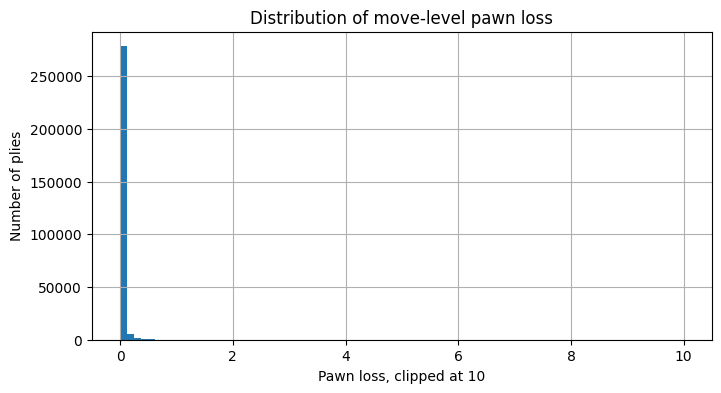

In [10]:
print("Eval summary")
display(plies_ml["eval_pawns"].describe(percentiles=[
  0.01,
  0.05,
  0.25,
  0.5,
  0.75,
  0.95,
  0.99,
]))

print("Pawn-loss summary")
display(plies_ml["pawn_loss"].describe(percentiles=[
  0.5,
  0.75,
  0.9,
  0.95,
  0.99,
  0.999,
]))

print("Move-level mistake/blunder fractions")
display(plies_ml[["is_mistake", "is_blunder"]].mean().to_frame("fraction"))

fig, ax = plt.subplots(figsize=(8, 4))
plies_ml["pawn_loss"].clip(0, 10).hist(bins=80, ax=ax)
ax.set_xlabel("Pawn loss, clipped at 10")
ax.set_ylabel("Number of plies")
ax.set_title("Distribution of move-level pawn loss")
plt.show()


## 7. Future-blunder target

The target asks:

> Does the same player blunder within their next `HORIZON_OWN_MOVES` moves?


In [11]:
def add_future_blunder_target_fast(df, horizon_own_moves):
  df = df.copy()
  df = df.sort_values([game_id_col, "mover", ply_col])

  keys = [game_id_col, "mover"]
  group = df.groupby(keys, sort=False)["is_blunder"]

  future_count = pd.Series(0, index=df.index, dtype=float)

  for step in range(1, horizon_own_moves + 1):
    future_count += group.shift(-step).fillna(0)

  df["future_blunder_count"] = future_count
  df["will_blunder_soon"] = (
    df["future_blunder_count"].gt(0).astype(int)
  )

  df = df.sort_values([game_id_col, ply_col]).reset_index(drop=True)

  return df


plies_ml = add_future_blunder_target_fast(
  plies_ml,
  HORIZON_OWN_MOVES,
)

print("Future-blunder target counts")
display(plies_ml["will_blunder_soon"].value_counts(dropna=False))
display(plies_ml["will_blunder_soon"].value_counts(
  normalize=True,
  dropna=False,
))

game_target = (
  pd.DataFrame({
    "game_id": plies_ml[game_id_col],
    "target": plies_ml["will_blunder_soon"],
  })
  .groupby("game_id")["target"]
  .max()
)

print("Games with at least one positive target")
display(game_target.value_counts(dropna=False))
display(game_target.value_counts(normalize=True, dropna=False))


Future-blunder target counts


will_blunder_soon
0    320177
1      1417
Name: count, dtype: int64

will_blunder_soon
0    0.995594
1    0.004406
Name: proportion, dtype: float64

Games with at least one positive target


target
0    4740
1     260
Name: count, dtype: int64

target
0    0.948
1    0.052
Name: proportion, dtype: float64

## 8. Legal pre-blunder features

These features use only information available up to the current position.

Leakage columns intentionally excluded:

- `eval_after_pawns`
- `eval_delta_pawns`
- `pawn_loss`
- `is_mistake`
- `is_blunder`
- `future_blunder_count`
- `will_blunder_soon`


In [12]:
def add_rolling_features(df):
  df = df.copy()
  df = df.sort_values([game_id_col, ply_col]).reset_index(drop=True)

  group = df.groupby(game_id_col, sort=False)

  df["abs_eval_pawns"] = df["eval_pawns"].abs()
  df["eval_sign"] = np.sign(df["eval_pawns"]).astype(float)

  df["eval_prev_1"] = group["eval_pawns"].shift(1)
  df["eval_prev_2"] = group["eval_pawns"].shift(2)
  df["eval_prev_4"] = group["eval_pawns"].shift(4)

  df["eval_change_prev_1"] = df["eval_pawns"] - df["eval_prev_1"]
  df["eval_change_prev_2"] = df["eval_pawns"] - df["eval_prev_2"]
  df["eval_change_prev_4"] = df["eval_pawns"] - df["eval_prev_4"]

  df["abs_eval_change_prev_1"] = df["eval_change_prev_1"].abs()
  df["abs_eval_change_prev_2"] = df["eval_change_prev_2"].abs()
  df["abs_eval_change_prev_4"] = df["eval_change_prev_4"].abs()

  df["game_ply_fraction"] = group.cumcount()
  max_ply = group["game_ply_fraction"].transform("max").replace(0, np.nan)
  df["game_ply_fraction"] = df["game_ply_fraction"] / max_ply

  df["phase"] = pd.cut(
    df["fullmove_number"].astype(float),
    bins=[0, 10, 25, 10_000],
    labels=["opening", "middlegame", "endgame"],
    include_lowest=True,
  )

  return df


def add_player_history_features(df):
  df = df.copy()
  df = df.sort_values([game_id_col, ply_col]).reset_index(drop=True)

  keys = [game_id_col, "mover"]
  group = df.groupby(keys, sort=False)

  prev_blunder = group["is_blunder"].shift(1).fillna(0)
  prev_mistake = group["is_mistake"].shift(1).fillna(0)
  prev_pawn_loss = group["pawn_loss"].shift(1)

  hist_keys = [df[game_id_col], df["mover"]]

  df["prev_own_blunders"] = (
    prev_blunder
    .groupby(hist_keys, sort=False)
    .cumsum()
  )

  df["prev_own_mistakes"] = (
    prev_mistake
    .groupby(hist_keys, sort=False)
    .cumsum()
  )

  df["prev_own_pawn_loss"] = prev_pawn_loss

  for window in [3, 5, 10]:
    shifted_loss = group["pawn_loss"].shift(1)

    rolled = (
      shifted_loss
      .groupby(hist_keys, sort=False)
      .rolling(window, min_periods=1)
      .mean()
    )

    df[f"prev_own_pawn_loss_mean_{window}"] = (
      rolled.reset_index(level=[0, 1], drop=True)
    )

  return df


plies_ml = add_rolling_features(plies_ml)
plies_ml = add_player_history_features(plies_ml)


In [13]:
candidate_features = [
  "eval_pawns",
  "abs_eval_pawns",
  "eval_sign",
  "fullmove_number",
  "game_ply_fraction",
  "eval_prev_1",
  "eval_prev_2",
  "eval_prev_4",
  "eval_change_prev_1",
  "eval_change_prev_2",
  "eval_change_prev_4",
  "abs_eval_change_prev_1",
  "abs_eval_change_prev_2",
  "abs_eval_change_prev_4",
  "prev_own_blunders",
  "prev_own_mistakes",
  "prev_own_pawn_loss",
  "prev_own_pawn_loss_mean_3",
  "prev_own_pawn_loss_mean_5",
  "prev_own_pawn_loss_mean_10",
  "mover",
  "phase",
]

feature_cols = [c for c in candidate_features if c in plies_ml.columns]

print("Feature columns:")
for col in feature_cols:
  print(" ", col)


Feature columns:
  eval_pawns
  abs_eval_pawns
  eval_sign
  fullmove_number
  game_ply_fraction
  eval_prev_1
  eval_prev_2
  eval_prev_4
  eval_change_prev_1
  eval_change_prev_2
  eval_change_prev_4
  abs_eval_change_prev_1
  abs_eval_change_prev_2
  abs_eval_change_prev_4
  prev_own_blunders
  prev_own_mistakes
  prev_own_pawn_loss
  prev_own_pawn_loss_mean_3
  prev_own_pawn_loss_mean_5
  prev_own_pawn_loss_mean_10
  mover
  phase


In [14]:
model_df = plies_ml.dropna(subset=["will_blunder_soon"]).copy()

# Remove last plies where the full future horizon cannot exist.
group = model_df.groupby(game_id_col, sort=False)
max_ply = group[ply_col].transform("max")
min_future_gap = 2 * HORIZON_OWN_MOVES
model_df = model_df[model_df[ply_col] <= max_ply - min_future_gap].copy()

X = model_df[feature_cols]
y = model_df["will_blunder_soon"].astype(int)
groups = model_df[game_id_col]

print("Model rows:", len(model_df))
print("Unique games:", groups.nunique())
print("Positive target rate:", y.mean())

print("Target counts")
display(y.value_counts(dropna=False))
display(y.value_counts(normalize=True, dropna=False))

display(X.head())


Model rows: 271611
Unique games: 4990
Positive target rate: 0.004506444878889294
Target counts


will_blunder_soon
0    270387
1      1224
Name: count, dtype: int64

will_blunder_soon
0    0.995494
1    0.004506
Name: proportion, dtype: float64

,eval_pawns,abs_eval_pawns,eval_sign,fullmove_number,game_ply_fraction,eval_prev_1,eval_prev_2,eval_prev_4,eval_change_prev_1,eval_change_prev_2,eval_change_prev_4,abs_eval_change_prev_1,abs_eval_change_prev_2,abs_eval_change_prev_4,prev_own_blunders,prev_own_mistakes,prev_own_pawn_loss,prev_own_pawn_loss_mean_3,prev_own_pawn_loss_mean_5,prev_own_pawn_loss_mean_10,mover,phase
0,0.15,0.15,1.0,1,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,white,opening
1,0.55,0.55,1.0,1,0.020833,0.15,NaN,NaN,0.40,NaN,NaN,0.40,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,black,opening
2,-0.48,0.48,-1.0,2,0.041667,0.55,0.15,NaN,-1.03,-0.63,NaN,1.03,0.63,NaN,0.0,0.0,0.0,0.0,0.0,0.0,white,opening
3,-0.42,0.42,-1.0,2,0.062500,-0.48,0.55,NaN,0.06,-0.97,NaN,0.06,0.97,NaN,0.0,0.0,0.0,0.0,0.0,0.0,black,opening
4,-0.51,0.51,-1.0,3,0.083333,-0.42,-0.48,0.15,-0.09,-0.03,-0.66,0.09,0.03,0.66,0.0,0.0,0.0,0.0,0.0,0.0,white,opening


## 9. Stratified split by game

We keep entire games together and stratify at the game level using:

```text
game target = max(will_blunder_soon within game)
```


In [15]:
def stratified_game_train_valid_test_split(
  X,
  y,
  groups,
  seed=RANDOM_STATE,
):
  game_df = (
    pd.DataFrame({
      "game_id": groups,
      "target": y,
    })
    .groupby("game_id", as_index=False)["target"]
    .max()
  )

  if game_df["target"].nunique() < 2:
    raise ValueError(
      "Only one game-level target class exists. Lower "
      "BLUNDER_PAWN_LOSS or increase N_GAMES_SAMPLE."
    )

  train_games, temp_games = train_test_split(
    game_df,
    train_size=0.70,
    random_state=seed,
    stratify=game_df["target"],
  )

  valid_games, test_games = train_test_split(
    temp_games,
    train_size=0.50,
    random_state=seed,
    stratify=temp_games["target"],
  )

  train_ids = set(train_games["game_id"])
  valid_ids = set(valid_games["game_id"])
  test_ids = set(test_games["game_id"])

  train_mask = groups.isin(train_ids)
  valid_mask = groups.isin(valid_ids)
  test_mask = groups.isin(test_ids)

  X_train = X.loc[train_mask]
  y_train = y.loc[train_mask]
  g_train = groups.loc[train_mask]

  X_valid = X.loc[valid_mask]
  y_valid = y.loc[valid_mask]
  g_valid = groups.loc[valid_mask]

  X_test = X.loc[test_mask]
  y_test = y.loc[test_mask]
  g_test = groups.loc[test_mask]

  for split_name, split_y in [
    ("train", y_train),
    ("valid", y_valid),
    ("test", y_test),
  ]:
    if split_y.nunique() < 2:
      raise ValueError(
        f"{split_name} has only one row-level target class. "
        "Increase N_GAMES_SAMPLE or lower BLUNDER_PAWN_LOSS."
      )

  return (
    X_train,
    X_valid,
    X_test,
    y_train,
    y_valid,
    y_test,
    g_train,
    g_valid,
    g_test,
  )


split = stratified_game_train_valid_test_split(X, y, groups)

(
  X_train,
  X_valid,
  X_test,
  y_train,
  y_valid,
  y_test,
  g_train,
  g_valid,
  g_test,
) = split

print("train:", X_train.shape, y_train.mean(), g_train.nunique())
print("valid:", X_valid.shape, y_valid.mean(), g_valid.nunique())
print("test: ", X_test.shape, y_test.mean(), g_test.nunique())

print("\nTrain target counts")
display(y_train.value_counts())

print("\nValid target counts")
display(y_valid.value_counts())

print("\nTest target counts")
display(y_test.value_counts())


train: (190489, 22) 0.004483198504900546 3493
valid: (40850, 22) 0.004332925336597307 748
test:  (40272, 22) 0.004792411601112436 749

Train target counts


will_blunder_soon
0    189635
1       854
Name: count, dtype: int64


Valid target counts


will_blunder_soon
0    40673
1      177
Name: count, dtype: int64


Test target counts


will_blunder_soon
0    40079
1      193
Name: count, dtype: int64

## 10. Shared preprocessing

Tree models use imputed numeric features plus one-hot categorical features.

Neural networks use imputed, scaled numeric features plus one-hot categorical
features, converted to dense arrays.


In [16]:
numeric_cols = [
  c for c in feature_cols
  if pd.api.types.is_numeric_dtype(X_train[c])
]

categorical_cols = [
  c for c in feature_cols
  if c not in numeric_cols
]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

numeric_preprocess_scaled = Pipeline([
  ("imputer", SimpleImputer(strategy="median")),
  ("scaler", StandardScaler()),
])

numeric_preprocess_unscaled = Pipeline([
  ("imputer", SimpleImputer(strategy="median")),
])

categorical_preprocess = Pipeline([
  ("imputer", SimpleImputer(strategy="most_frequent")),
  ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess_tree = ColumnTransformer([
  ("num", numeric_preprocess_unscaled, numeric_cols),
  ("cat", categorical_preprocess, categorical_cols),
])

preprocess_nn = ColumnTransformer([
  ("num", numeric_preprocess_scaled, numeric_cols),
  ("cat", categorical_preprocess, categorical_cols),
])

preprocess_linear = ColumnTransformer([
  ("num", numeric_preprocess_scaled, numeric_cols),
  ("cat", categorical_preprocess, categorical_cols),
])


Numeric columns: ['eval_pawns', 'abs_eval_pawns', 'eval_sign', 'fullmove_number', 'game_ply_fraction', 'eval_prev_1', 'eval_prev_2', 'eval_prev_4', 'eval_change_prev_1', 'eval_change_prev_2', 'eval_change_prev_4', 'abs_eval_change_prev_1', 'abs_eval_change_prev_2', 'abs_eval_change_prev_4', 'prev_own_blunders', 'prev_own_mistakes', 'prev_own_pawn_loss', 'prev_own_pawn_loss_mean_3', 'prev_own_pawn_loss_mean_5', 'prev_own_pawn_loss_mean_10']
Categorical columns: ['mover', 'phase']


## 11. Utility functions for metrics, thresholds, and plots


In [17]:
def get_score(model, X_eval):
  if hasattr(model, "predict_proba"):
    proba = model.predict_proba(X_eval)

    if proba.shape[1] == 1:
      only_class = model.classes_[0]
      if only_class == 1:
        return np.ones(len(X_eval))
      return np.zeros(len(X_eval))

    positive_index = list(model.classes_).index(1)
    return proba[:, positive_index]

  if hasattr(model, "decision_function"):
    score = model.decision_function(X_eval)
    return 1 / (1 + np.exp(-score))

  return model.predict(X_eval)


def find_best_threshold(y_true, score, metric="f1"):
  rows = []

  for threshold in np.linspace(0.01, 0.99, 99):
    pred = (score >= threshold).astype(int)

    rows.append({
      "threshold": threshold,
      "f1": f1_score(y_true, pred),
      "balanced_acc": balanced_accuracy_score(y_true, pred),
      "pred_positive_rate": pred.mean(),
    })

  threshold_df = pd.DataFrame(rows)

  if metric not in threshold_df.columns:
    raise ValueError(f"Unknown threshold metric: {metric}")

  best = threshold_df.sort_values(metric, ascending=False).iloc[0]

  return float(best["threshold"]), threshold_df


def evaluate_scores(name, y_true, score, threshold=0.5):
  pred = (score >= threshold).astype(int)

  return {
    "model": name,
    "threshold": threshold,
    "roc_auc": roc_auc_score(y_true, score),
    "avg_precision": average_precision_score(y_true, score),
    "balanced_acc": balanced_accuracy_score(y_true, pred),
    "f1": f1_score(y_true, pred),
    "pred_positive_rate": pred.mean(),
    "true_positive_rate": y_true.mean(),
  }


def evaluate_model(name, model, X_eval, y_eval, threshold=0.5):
  score = get_score(model, X_eval)
  return evaluate_scores(name, y_eval, score, threshold)


def fit_and_score_sklearn_model(name, model):
  start = time.time()
  model.fit(X_train, y_train)
  fit_seconds = time.time() - start

  valid_score = get_score(model, X_valid)
  threshold, threshold_df = find_best_threshold(y_valid, valid_score)

  valid_metrics_05 = evaluate_scores(
    name,
    y_valid,
    valid_score,
    threshold=0.5,
  )

  valid_metrics_opt = evaluate_scores(
    name,
    y_valid,
    valid_score,
    threshold=threshold,
  )

  test_score = get_score(model, X_test)

  test_metrics_opt = evaluate_scores(
    name,
    y_test,
    test_score,
    threshold=threshold,
  )

  for row in [valid_metrics_05, valid_metrics_opt, test_metrics_opt]:
    row["fit_seconds"] = fit_seconds

  artifact = {
    "name": name,
    "model": model,
    "threshold": threshold,
    "threshold_df": threshold_df,
    "valid_score": valid_score,
    "test_score": test_score,
    "valid_metrics_05": valid_metrics_05,
    "valid_metrics_opt": valid_metrics_opt,
    "test_metrics_opt": test_metrics_opt,
  }

  return artifact


def plot_threshold_scan(artifact):
  threshold_df = artifact["threshold_df"]

  fig, ax = plt.subplots(figsize=(8, 4))
  ax.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
  ax.plot(
    threshold_df["threshold"],
    threshold_df["balanced_acc"],
    label="Balanced accuracy",
  )
  ax.axvline(
    artifact["threshold"],
    linestyle="--",
    label="Selected threshold",
  )
  ax.set_xlabel("Threshold")
  ax.set_ylabel("Validation score")
  ax.set_title(f"Threshold scan: {artifact['name']}")
  ax.legend()
  plt.show()


def plot_confusion_matrix_for_artifact(artifact):
  score = artifact["test_score"]
  pred = (score >= artifact["threshold"]).astype(int)

  disp = ConfusionMatrixDisplay(confusion_matrix(y_test, pred))
  disp.plot()
  plt.title(f"Test confusion matrix: {artifact['name']}")
  plt.show()


def plot_single_roc_pr(artifact):
  score = artifact["test_score"]

  RocCurveDisplay.from_predictions(y_test, score)
  plt.title(f"Test ROC: {artifact['name']}")
  plt.show()

  PrecisionRecallDisplay.from_predictions(y_test, score)
  plt.title(f"Test precision-recall: {artifact['name']}")
  plt.show()


artifacts = {}
valid_rows = []
test_rows = []


## 12. Baseline sanity models

These are not the final goal, but they anchor the comparison.


In [18]:
baseline_models = {
  "dummy_prior": Pipeline([
    ("preprocess", preprocess_tree),
    ("model", DummyClassifier(strategy="prior")),
  ]),
  "logreg_baseline": Pipeline([
    ("preprocess", preprocess_linear),
    ("model", LogisticRegression(
      max_iter=1000,
      class_weight="balanced",
      random_state=RANDOM_STATE,
    )),
  ]),
}

for name, model in baseline_models.items():
  print(f"Training {name}...")
  artifact = fit_and_score_sklearn_model(name, model)
  artifacts[name] = artifact

  valid_rows.append({
    **artifact["valid_metrics_05"],
    "split": "valid",
    "setting": "threshold_0.5",
  })
  valid_rows.append({
    **artifact["valid_metrics_opt"],
    "split": "valid",
    "setting": "threshold_optimized",
  })
  test_rows.append({
    **artifact["test_metrics_opt"],
    "split": "test",
    "setting": "threshold_optimized",
  })

summary_valid = pd.DataFrame(valid_rows)
summary_test = pd.DataFrame(test_rows)

display(summary_valid.sort_values("avg_precision", ascending=False))
display(summary_test.sort_values("avg_precision", ascending=False))


Training dummy_prior...
Training logreg_baseline...


,model,threshold,roc_auc,avg_precision,balanced_acc,f1,pred_positive_rate,true_positive_rate,fit_seconds,split,setting
2,logreg_baseline,0.50,0.873965,0.034002,0.803927,0.028859,0.253537,0.004333,0.536732,valid,threshold_0.5
3,logreg_baseline,0.96,0.873965,0.034002,0.563310,0.084806,0.009523,0.004333,0.536732,valid,threshold_optimized
0,dummy_prior,0.50,0.500000,0.004333,0.500000,0.000000,0.000000,0.004333,0.409851,valid,threshold_0.5
1,dummy_prior,0.01,0.500000,0.004333,0.500000,0.000000,0.000000,0.004333,0.409851,valid,threshold_optimized


,model,threshold,roc_auc,avg_precision,balanced_acc,f1,pred_positive_rate,true_positive_rate,fit_seconds,split,setting
1,logreg_baseline,0.96,0.892193,0.038053,0.54995,0.073555,0.009386,0.004792,0.536732,test,threshold_optimized
0,dummy_prior,0.01,0.500000,0.004792,0.50000,0.000000,0.000000,0.004792,0.409851,test,threshold_optimized


## 13. XGBoost baseline


In [19]:
if HAS_XGBOOST:
  from xgboost import XGBClassifier

  scale_pos_weight = y_train.eq(0).sum() / y_train.eq(1).sum()

  xgb_baseline = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", XGBClassifier(
      n_estimators=350,
      max_depth=4,
      learning_rate=0.05,
      subsample=0.8,
      colsample_bytree=0.8,
      min_child_weight=5,
      reg_lambda=2.0,
      objective="binary:logistic",
      eval_metric="aucpr",
      scale_pos_weight=scale_pos_weight,
      random_state=RANDOM_STATE,
      n_jobs=-1,
      tree_method="hist",
    )),
  ])

  artifact = fit_and_score_sklearn_model("xgboost_baseline", xgb_baseline)
  artifacts["xgboost_baseline"] = artifact

  valid_rows.append({
    **artifact["valid_metrics_05"],
    "split": "valid",
    "setting": "threshold_0.5",
  })
  valid_rows.append({
    **artifact["valid_metrics_opt"],
    "split": "valid",
    "setting": "threshold_optimized",
  })
  test_rows.append({
    **artifact["test_metrics_opt"],
    "split": "test",
    "setting": "threshold_optimized",
  })

  display(pd.DataFrame([
    artifact["valid_metrics_05"],
    artifact["valid_metrics_opt"],
    artifact["test_metrics_opt"],
  ]))

else:
  print("Skipping XGBoost because xgboost is not installed.")


,model,threshold,roc_auc,avg_precision,balanced_acc,f1,pred_positive_rate,true_positive_rate,fit_seconds
0,xgboost_baseline,0.50,0.896067,0.044443,0.793235,0.054464,0.105337,0.004333,1.117009
1,xgboost_baseline,0.87,0.896067,0.044443,0.615566,0.094522,0.018458,0.004333,1.117009
2,xgboost_baseline,0.87,0.912163,0.045556,0.616069,0.106077,0.017680,0.004792,1.117009


## 14. XGBoost hyperparameter optimization

The objective optimizes validation average precision. The threshold is optimized
after the model is selected.


In [20]:
if HAS_XGBOOST and HAS_OPTUNA and RUN_HYPERPARAM_OPT:
  import optuna
  from xgboost import XGBClassifier

  scale_pos_weight = y_train.eq(0).sum() / y_train.eq(1).sum()

  def objective_xgb(trial):
    params = {
      "n_estimators": trial.suggest_int("n_estimators", 200, 700),
      "max_depth": trial.suggest_int("max_depth", 2, 8),
      "learning_rate": trial.suggest_float(
        "learning_rate",
        0.01,
        0.12,
        log=True,
      ),
      "subsample": trial.suggest_float("subsample", 0.6, 1.0),
      "colsample_bytree": trial.suggest_float(
        "colsample_bytree",
        0.6,
        1.0,
      ),
      "min_child_weight": trial.suggest_float(
        "min_child_weight",
        1.0,
        20.0,
        log=True,
      ),
      "reg_lambda": trial.suggest_float(
        "reg_lambda",
        0.1,
        20.0,
        log=True,
      ),
      "reg_alpha": trial.suggest_float(
        "reg_alpha",
        1e-4,
        5.0,
        log=True,
      ),
    }

    model = Pipeline([
      ("preprocess", preprocess_tree),
      ("model", XGBClassifier(
        **params,
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
      )),
    ])

    model.fit(X_train, y_train)
    score = get_score(model, X_valid)

    return average_precision_score(y_valid, score)


  study_xgb = optuna.create_study(direction="maximize")
  study_xgb.optimize(
    objective_xgb,
    n_trials=OPTUNA_TRIALS,
    timeout=OPTUNA_TIMEOUT_SECONDS,
    show_progress_bar=True,
  )

  print("Best XGBoost AP:", study_xgb.best_value)
  print("Best XGBoost params")
  display(study_xgb.best_params)

  best_params = study_xgb.best_params.copy()

  xgb_optimized = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", XGBClassifier(
      **best_params,
      objective="binary:logistic",
      eval_metric="aucpr",
      scale_pos_weight=scale_pos_weight,
      random_state=RANDOM_STATE,
      n_jobs=-1,
      tree_method="hist",
    )),
  ])

  artifact = fit_and_score_sklearn_model(
    "xgboost_optimized",
    xgb_optimized,
  )
  artifacts["xgboost_optimized"] = artifact

  valid_rows.append({
    **artifact["valid_metrics_05"],
    "split": "valid",
    "setting": "threshold_0.5",
  })
  valid_rows.append({
    **artifact["valid_metrics_opt"],
    "split": "valid",
    "setting": "threshold_optimized",
  })
  test_rows.append({
    **artifact["test_metrics_opt"],
    "split": "test",
    "setting": "threshold_optimized",
  })

  display(pd.DataFrame([
    artifact["valid_metrics_05"],
    artifact["valid_metrics_opt"],
    artifact["test_metrics_opt"],
  ]))

elif HAS_XGBOOST:
  print("Skipping XGBoost optimization.")
else:
  print("Skipping XGBoost optimization because xgboost is not installed.")


[I 2026-06-05 21:29:00,946] A new study created in memory with name: no-name-0d3f40a8-4040-4173-be43-05a6d2882126


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-05 21:29:02,132] Trial 0 finished with value: 0.03388779249578744 and parameters: {'n_estimators': 322, 'max_depth': 5, 'learning_rate': 0.11039078209546668, 'subsample': 0.8882385053880595, 'colsample_bytree': 0.749615587910648, 'min_child_weight': 1.04634537096405, 'reg_lambda': 0.4978257528242486, 'reg_alpha': 0.00034625792357557424}. Best is trial 0 with value: 0.03388779249578744.
[I 2026-06-05 21:29:03,366] Trial 1 finished with value: 0.04371902081579929 and parameters: {'n_estimators': 619, 'max_depth': 2, 'learning_rate': 0.06957286193914931, 'subsample': 0.8106523381302556, 'colsample_bytree': 0.9663035189620197, 'min_child_weight': 9.578903744218938, 'reg_lambda': 8.368190555323896, 'reg_alpha': 0.02036431816101582}. Best is trial 1 with value: 0.04371902081579929.
[I 2026-06-05 21:29:04,260] Trial 2 finished with value: 0.036847433569972214 and parameters: {'n_estimators': 335, 'max_depth': 2, 'learning_rate': 0.05652754211031863, 'subsample': 0.681005986329493, 

{'n_estimators': 619,
 'max_depth': 2,
 'learning_rate': 0.06957286193914931,
 'subsample': 0.8106523381302556,
 'colsample_bytree': 0.9663035189620197,
 'min_child_weight': 9.578903744218938,
 'reg_lambda': 8.368190555323896,
 'reg_alpha': 0.02036431816101582}

,model,threshold,roc_auc,avg_precision,balanced_acc,f1,pred_positive_rate,true_positive_rate,fit_seconds
0,xgboost_optimized,0.5,0.902728,0.043719,0.816492,0.045289,0.143770,0.004333,1.212657
1,xgboost_optimized,0.9,0.902728,0.043719,0.633324,0.092559,0.022644,0.004333,1.212657
2,xgboost_optimized,0.9,0.914659,0.067261,0.642957,0.112919,0.021156,0.004792,1.212657


## 15. LightGBM baseline


In [21]:
if HAS_LIGHTGBM:
  from lightgbm import LGBMClassifier

  scale_pos_weight = y_train.eq(0).sum() / y_train.eq(1).sum()

  lgbm_baseline = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", LGBMClassifier(
      n_estimators=500,
      num_leaves=31,
      learning_rate=0.04,
      subsample=0.8,
      colsample_bytree=0.8,
      min_child_samples=50,
      reg_lambda=2.0,
      objective="binary",
      scale_pos_weight=scale_pos_weight,
      random_state=RANDOM_STATE,
      n_jobs=-1,
      verbose=-1,
    )),
  ])

  artifact = fit_and_score_sklearn_model("lightgbm_baseline", lgbm_baseline)
  artifacts["lightgbm_baseline"] = artifact

  valid_rows.append({
    **artifact["valid_metrics_05"],
    "split": "valid",
    "setting": "threshold_0.5",
  })
  valid_rows.append({
    **artifact["valid_metrics_opt"],
    "split": "valid",
    "setting": "threshold_optimized",
  })
  test_rows.append({
    **artifact["test_metrics_opt"],
    "split": "test",
    "setting": "threshold_optimized",
  })

  display(pd.DataFrame([
    artifact["valid_metrics_05"],
    artifact["valid_metrics_opt"],
    artifact["test_metrics_opt"],
  ]))

else:
  print("Skipping LightGBM because lightgbm is not installed.")


,model,threshold,roc_auc,avg_precision,balanced_acc,f1,pred_positive_rate,true_positive_rate,fit_seconds
0,lightgbm_baseline,0.50,0.876433,0.042726,0.646029,0.068884,0.036891,0.004333,2.886968
1,lightgbm_baseline,0.75,0.876433,0.042726,0.592810,0.099291,0.012925,0.004333,2.886968
2,lightgbm_baseline,0.75,0.892089,0.036268,0.569191,0.083095,0.012540,0.004792,2.886968


## 16. LightGBM hyperparameter optimization


In [22]:
if HAS_LIGHTGBM and HAS_OPTUNA and RUN_HYPERPARAM_OPT:
  import optuna
  from lightgbm import LGBMClassifier

  scale_pos_weight = y_train.eq(0).sum() / y_train.eq(1).sum()

  def objective_lgbm(trial):
    params = {
      "n_estimators": trial.suggest_int("n_estimators", 250, 900),
      "num_leaves": trial.suggest_int("num_leaves", 15, 127),
      "learning_rate": trial.suggest_float(
        "learning_rate",
        0.01,
        0.12,
        log=True,
      ),
      "subsample": trial.suggest_float("subsample", 0.6, 1.0),
      "colsample_bytree": trial.suggest_float(
        "colsample_bytree",
        0.6,
        1.0,
      ),
      "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
      "reg_lambda": trial.suggest_float(
        "reg_lambda",
        0.1,
        20.0,
        log=True,
      ),
      "reg_alpha": trial.suggest_float(
        "reg_alpha",
        1e-4,
        5.0,
        log=True,
      ),
    }

    model = Pipeline([
      ("preprocess", preprocess_tree),
      ("model", LGBMClassifier(
        **params,
        objective="binary",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
      )),
    ])

    model.fit(X_train, y_train)
    score = get_score(model, X_valid)

    return average_precision_score(y_valid, score)


  study_lgbm = optuna.create_study(direction="maximize")
  study_lgbm.optimize(
    objective_lgbm,
    n_trials=OPTUNA_TRIALS,
    timeout=OPTUNA_TIMEOUT_SECONDS,
    show_progress_bar=True,
  )

  print("Best LightGBM AP:", study_lgbm.best_value)
  print("Best LightGBM params")
  display(study_lgbm.best_params)

  best_params = study_lgbm.best_params.copy()

  lgbm_optimized = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", LGBMClassifier(
      **best_params,
      objective="binary",
      scale_pos_weight=scale_pos_weight,
      random_state=RANDOM_STATE,
      n_jobs=-1,
      verbose=-1,
    )),
  ])

  artifact = fit_and_score_sklearn_model(
    "lightgbm_optimized",
    lgbm_optimized,
  )
  artifacts["lightgbm_optimized"] = artifact

  valid_rows.append({
    **artifact["valid_metrics_05"],
    "split": "valid",
    "setting": "threshold_0.5",
  })
  valid_rows.append({
    **artifact["valid_metrics_opt"],
    "split": "valid",
    "setting": "threshold_optimized",
  })
  test_rows.append({
    **artifact["test_metrics_opt"],
    "split": "test",
    "setting": "threshold_optimized",
  })

  display(pd.DataFrame([
    artifact["valid_metrics_05"],
    artifact["valid_metrics_opt"],
    artifact["test_metrics_opt"],
  ]))

elif HAS_LIGHTGBM:
  print("Skipping LightGBM optimization.")
else:
  print("Skipping LightGBM optimization because lightgbm is not installed.")


[I 2026-06-05 21:29:09,619] A new study created in memory with name: no-name-f1fbe236-1fbd-4285-b86f-b1d3c11e0853


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-05 21:29:24,578] Trial 0 finished with value: 0.03449463144715081 and parameters: {'n_estimators': 789, 'num_leaves': 126, 'learning_rate': 0.018759632419306, 'subsample': 0.9083074064344895, 'colsample_bytree': 0.9744211228353757, 'min_child_samples': 146, 'reg_lambda': 0.7518352624158529, 'reg_alpha': 0.006638942856817238}. Best is trial 0 with value: 0.03449463144715081.
[I 2026-06-05 21:29:30,860] Trial 1 finished with value: 0.013040671524016494 and parameters: {'n_estimators': 623, 'num_leaves': 63, 'learning_rate': 0.10324034399267543, 'subsample': 0.6348253039336421, 'colsample_bytree': 0.6929277391286643, 'min_child_samples': 188, 'reg_lambda': 4.58284103475936, 'reg_alpha': 0.0015128376176928168}. Best is trial 0 with value: 0.03449463144715081.
[I 2026-06-05 21:29:36,227] Trial 2 finished with value: 0.04152975939177819 and parameters: {'n_estimators': 649, 'num_leaves': 45, 'learning_rate': 0.014504392193423598, 'subsample': 0.7831880854340347, 'colsample_bytree'

{'n_estimators': 649,
 'num_leaves': 45,
 'learning_rate': 0.014504392193423598,
 'subsample': 0.7831880854340347,
 'colsample_bytree': 0.9837694765959231,
 'min_child_samples': 198,
 'reg_lambda': 0.3624126416913272,
 'reg_alpha': 0.00021138765180169164}

,model,threshold,roc_auc,avg_precision,balanced_acc,f1,pred_positive_rate,true_positive_rate,fit_seconds
0,lightgbm_optimized,0.50,0.873344,0.04153,0.702838,0.068326,0.053709,0.004333,4.922658
1,lightgbm_optimized,0.75,0.873344,0.04153,0.629481,0.102833,0.018996,0.004333,4.922658
2,lightgbm_optimized,0.75,0.895086,0.04960,0.615407,0.100209,0.018996,0.004792,4.922658


## 17. PyTorch utilities

The PyTorch models below are wrapped in a scikit-learn style class so we can
reuse the same metric and permutation-importance code.

The first model is a normal MLP.

The second is a small FT-Transformer-style model. It treats each transformed
tabular feature as a token, embeds it, applies self-attention, and then predicts
from a learned CLS token. This is intentionally more advanced than needed, but
it is a useful edge-of-the-map experiment.


In [23]:
def sample_rows_for_nn(X, y, max_rows, seed=RANDOM_STATE):
  if max_rows is None or len(X) <= max_rows:
    return X, y

  sampled_idx, _ = train_test_split(
    X.index,
    train_size=max_rows,
    random_state=seed,
    stratify=y,
  )

  return X.loc[sampled_idx], y.loc[sampled_idx]


def fit_and_score_nn_model(name, model):
  X_train_nn, y_train_nn = sample_rows_for_nn(
    X_train,
    y_train,
    NN_TRAIN_MAX_ROWS,
    seed=RANDOM_STATE,
  )

  print("=" * 80)
  print(f"Training {name}")
  print(f"Full train rows: {len(X_train):,}")
  print(f"NN train rows:   {len(X_train_nn):,}")
  print(f"Valid rows:      {len(X_valid):,}")
  print(f"Test rows:       {len(X_test):,}")
  print("Target rate in NN train:", y_train_nn.mean())
  print("=" * 80)

  start = time.time()

  print("[1/4] Fitting preprocessing + neural network...")
  model.fit(X_train_nn, y_train_nn)
  fit_seconds = time.time() - start
  print(f"Fit finished in {fit_seconds:.1f} seconds")

  print("[2/4] Predicting validation scores...")
  valid_score = get_score(model, X_valid)

  print("[3/4] Optimizing threshold on validation set...")
  threshold, threshold_df = find_best_threshold(y_valid, valid_score)

  valid_metrics_05 = evaluate_scores(
    name,
    y_valid,
    valid_score,
    threshold=0.5,
  )

  valid_metrics_opt = evaluate_scores(
    name,
    y_valid,
    valid_score,
    threshold=threshold,
  )

  print("[4/4] Predicting test scores...")
  test_score = get_score(model, X_test)

  test_metrics_opt = evaluate_scores(
    name,
    y_test,
    test_score,
    threshold=threshold,
  )

  for row in [valid_metrics_05, valid_metrics_opt, test_metrics_opt]:
    row["fit_seconds"] = fit_seconds
    row["nn_train_rows"] = len(X_train_nn)

  artifact = {
    "name": name,
    "model": model,
    "threshold": threshold,
    "threshold_df": threshold_df,
    "valid_score": valid_score,
    "test_score": test_score,
    "valid_metrics_05": valid_metrics_05,
    "valid_metrics_opt": valid_metrics_opt,
    "test_metrics_opt": test_metrics_opt,
  }

  print("Done.")
  return artifact

In [24]:
if HAS_TORCH:
  mlp_baseline = Pipeline([
    ("preprocess", preprocess_nn),
    ("model", TorchTabularClassifier(
      model_type="mlp",
      hidden_dim=128,
      depth=3,
      dropout=0.15,
      lr=NN_LEARNING_RATE,
      weight_decay=1e-4,
      batch_size=NN_BATCH_SIZE,
      max_epochs=NN_MAX_EPOCHS,
      patience=NN_PATIENCE,
      random_state=RANDOM_STATE,
      verbose=True,
    )),
  ])

  artifact = fit_and_score_nn_model(
    "pytorch_mlp_baseline",
    mlp_baseline,
  )

  artifacts["pytorch_mlp_baseline"] = artifact

  valid_rows.append({
    **artifact["valid_metrics_05"],
    "split": "valid",
    "setting": "threshold_0.5",
  })

  valid_rows.append({
    **artifact["valid_metrics_opt"],
    "split": "valid",
    "setting": "threshold_optimized",
  })

  test_rows.append({
    **artifact["test_metrics_opt"],
    "split": "test",
    "setting": "threshold_optimized",
  })

  display(pd.DataFrame([
    artifact["valid_metrics_05"],
    artifact["valid_metrics_opt"],
    artifact["test_metrics_opt"],
  ]))

  hist = artifact["model"].named_steps["model"].history_
  hist_df = pd.DataFrame(hist)

  fig, ax = plt.subplots(figsize=(8, 4))
  ax.plot(hist_df["epoch"], hist_df["val_avg_precision"])
  ax.set_xlabel("Epoch")
  ax.set_ylabel("Internal validation average precision")
  ax.set_title("PyTorch MLP training curve")
  plt.show()

else:
  print("Skipping PyTorch MLP because torch is not installed.")

NameError: name 'TorchTabularClassifier' is not defined

In [24]:
if HAS_TORCH:
  def to_dense_float32(x):
    if hasattr(x, "toarray"):
      x = x.toarray()
    return np.asarray(x, dtype=np.float32)


  class TorchMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, depth=3, dropout=0.15):
      super().__init__()

      layers = []
      in_dim = input_dim

      for _ in range(depth):
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.BatchNorm1d(hidden_dim))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout))
        in_dim = hidden_dim

      layers.append(nn.Linear(in_dim, 1))
      self.net = nn.Sequential(*layers)

    def forward(self, x):
      return self.net(x).squeeze(-1)


  class NumericTokenizer(nn.Module):
    def __init__(self, n_features, d_token):
      super().__init__()
      self.weight = nn.Parameter(torch.randn(n_features, d_token) * 0.02)
      self.bias = nn.Parameter(torch.zeros(n_features, d_token))

    def forward(self, x):
      return x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0)


  class FTTransformerLite(nn.Module):
    def __init__(
      self,
      n_features,
      d_token=32,
      n_heads=4,
      n_layers=2,
      dropout=0.15,
    ):
      super().__init__()

      self.tokenizer = NumericTokenizer(n_features, d_token)
      self.cls = nn.Parameter(torch.zeros(1, 1, d_token))

      encoder_layer = nn.TransformerEncoderLayer(
        d_model=d_token,
        nhead=n_heads,
        dim_feedforward=4 * d_token,
        dropout=dropout,
        batch_first=True,
        activation="gelu",
      )

      self.encoder = nn.TransformerEncoder(
        encoder_layer,
        num_layers=n_layers,
      )

      self.head = nn.Sequential(
        nn.LayerNorm(d_token),
        nn.Linear(d_token, 1),
      )

    def forward(self, x):
      tokens = self.tokenizer(x)
      cls = self.cls.expand(x.shape[0], -1, -1)
      tokens = torch.cat([cls, tokens], dim=1)
      encoded = self.encoder(tokens)
      cls_out = encoded[:, 0, :]
      return self.head(cls_out).squeeze(-1)


  class TorchTabularClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
      self,
      model_type="mlp",
      hidden_dim=128,
      depth=3,
      dropout=0.15,
      lr=1e-3,
      weight_decay=1e-4,
      batch_size=4096,
      max_epochs=20,
      patience=4,
      d_token=32,
      n_heads=4,
      n_layers=2,
      random_state=RANDOM_STATE,
      verbose=False,
    ):
      self.model_type = model_type
      self.hidden_dim = hidden_dim
      self.depth = depth
      self.dropout = dropout
      self.lr = lr
      self.weight_decay = weight_decay
      self.batch_size = batch_size
      self.max_epochs = max_epochs
      self.patience = patience
      self.d_token = d_token
      self.n_heads = n_heads
      self.n_layers = n_layers
      self.random_state = random_state
      self.verbose = verbose

    def _make_model(self, input_dim):
      if self.model_type == "mlp":
        return TorchMLP(
          input_dim=input_dim,
          hidden_dim=self.hidden_dim,
          depth=self.depth,
          dropout=self.dropout,
        )

      if self.model_type == "ft_transformer":
        return FTTransformerLite(
          n_features=input_dim,
          d_token=self.d_token,
          n_heads=self.n_heads,
          n_layers=self.n_layers,
          dropout=self.dropout,
        )

      raise ValueError(f"Unknown model_type: {self.model_type}")

    def fit(self, X, y):
      torch.manual_seed(self.random_state)

      X = to_dense_float32(X)
      y = np.asarray(y, dtype=np.float32)

      X_train_arr, X_val_arr, y_train_arr, y_val_arr = train_test_split(
        X,
        y,
        test_size=0.15,
        random_state=self.random_state,
        stratify=y,
      )

      self.classes_ = np.array([0, 1])
      self.input_dim_ = X.shape[1]
      self.model_ = self._make_model(self.input_dim_).to(DEVICE)

      pos = max(float((y_train_arr == 1).sum()), 1.0)
      neg = max(float((y_train_arr == 0).sum()), 1.0)
      pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(DEVICE)

      loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
      optimizer = torch.optim.AdamW(
        self.model_.parameters(),
        lr=self.lr,
        weight_decay=self.weight_decay,
      )

      train_ds = TensorDataset(
        torch.tensor(X_train_arr),
        torch.tensor(y_train_arr),
      )
      val_x = torch.tensor(X_val_arr).to(DEVICE)
      val_y = torch.tensor(y_val_arr).to(DEVICE)

      train_loader = DataLoader(
        train_ds,
        batch_size=self.batch_size,
        shuffle=True,
        drop_last=False,
      )

      best_ap = -np.inf
      best_state = None
      bad_epochs = 0
      self.history_ = []

      for epoch in range(self.max_epochs):
        self.model_.train()
        train_loss_sum = 0.0
        n_seen = 0

        for xb, yb in train_loader:
          xb = xb.to(DEVICE)
          yb = yb.to(DEVICE)

          optimizer.zero_grad()
          logits = self.model_(xb)
          loss = loss_fn(logits, yb)
          loss.backward()
          optimizer.step()

          train_loss_sum += float(loss.item()) * len(xb)
          n_seen += len(xb)

        self.model_.eval()
        with torch.no_grad():
          val_logits = self.model_(val_x)
          val_prob = torch.sigmoid(val_logits).cpu().numpy()

        val_ap = average_precision_score(y_val_arr, val_prob)
        train_loss = train_loss_sum / max(n_seen, 1)

        self.history_.append({
          "epoch": epoch,
          "train_loss": train_loss,
          "val_avg_precision": val_ap,
        })

        if self.verbose:
          print(
            f"epoch={epoch:03d} "
            f"train_loss={train_loss:.4f} "
            f"val_ap={val_ap:.4f}"
          )

        if val_ap > best_ap:
          best_ap = val_ap
          best_state = {
            k: v.detach().cpu().clone()
            for k, v in self.model_.state_dict().items()
          }
          bad_epochs = 0
        else:
          bad_epochs += 1

        if bad_epochs >= self.patience:
          break

      if best_state is not None:
        self.model_.load_state_dict(best_state)

      self.best_val_ap_ = best_ap
      return self

    def predict_proba(self, X):
      X = to_dense_float32(X)
      self.model_.eval()

      probs = []

      with torch.no_grad():
        for start in range(0, len(X), self.batch_size):
          xb = torch.tensor(X[start:start + self.batch_size]).to(DEVICE)
          logits = self.model_(xb)
          prob = torch.sigmoid(logits).cpu().numpy()
          probs.append(prob)

      p1 = np.concatenate(probs)
      p0 = 1 - p1

      return np.vstack([p0, p1]).T

    def predict(self, X):
      return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


## 18. PyTorch MLP baseline


In [25]:
if HAS_TORCH:
  mlp_baseline = Pipeline([
    ("preprocess", preprocess_nn),
    ("model", TorchTabularClassifier(
      model_type="mlp",
      hidden_dim=128,
      depth=3,
      dropout=0.15,
      lr=NN_LEARNING_RATE,
      weight_decay=1e-4,
      batch_size=NN_BATCH_SIZE,
      max_epochs=NN_MAX_EPOCHS,
      patience=NN_PATIENCE,
      random_state=RANDOM_STATE,
      verbose=True,
    )),
  ])

  artifact = fit_and_score_sklearn_model("pytorch_mlp_baseline", mlp_baseline)
  artifacts["pytorch_mlp_baseline"] = artifact

  valid_rows.append({
    **artifact["valid_metrics_05"],
    "split": "valid",
    "setting": "threshold_0.5",
  })
  valid_rows.append({
    **artifact["valid_metrics_opt"],
    "split": "valid",
    "setting": "threshold_optimized",
  })
  test_rows.append({
    **artifact["test_metrics_opt"],
    "split": "test",
    "setting": "threshold_optimized",
  })

  display(pd.DataFrame([
    artifact["valid_metrics_05"],
    artifact["valid_metrics_opt"],
    artifact["test_metrics_opt"],
  ]))

  hist = artifact["model"].named_steps["model"].history_
  hist_df = pd.DataFrame(hist)

  fig, ax = plt.subplots(figsize=(8, 4))
  ax.plot(hist_df["epoch"], hist_df["val_avg_precision"])
  ax.set_xlabel("Epoch")
  ax.set_ylabel("Internal validation average precision")
  ax.set_title("PyTorch MLP training curve")
  plt.show()

else:
  print("Skipping PyTorch MLP because torch is not installed.")


: 

: 

## 19. PyTorch MLP hyperparameter optimization


In [ ]:
if HAS_TORCH and HAS_OPTUNA and RUN_HYPERPARAM_OPT:
  import optuna

  def objective_mlp(trial):
    hidden_dim = trial.suggest_categorical("hidden_dim", [64, 128, 256])
    depth = trial.suggest_int("depth", 2, 5)
    dropout = trial.suggest_float("dropout", 0.05, 0.35)
    lr = trial.suggest_float("lr", 3e-4, 3e-3, log=True)
    weight_decay = trial.suggest_float(
      "weight_decay",
      1e-6,
      1e-2,
      log=True,
    )

    model = Pipeline([
      ("preprocess", preprocess_nn),
      ("model", TorchTabularClassifier(
        model_type="mlp",
        hidden_dim=hidden_dim,
        depth=depth,
        dropout=dropout,
        lr=lr,
        weight_decay=weight_decay,
        batch_size=NN_BATCH_SIZE,
        max_epochs=max(8, NN_MAX_EPOCHS // 2),
        patience=max(2, NN_PATIENCE),
        random_state=RANDOM_STATE,
        verbose=False,
      )),
    ])

    model.fit(X_train, y_train)
    score = get_score(model, X_valid)

    return average_precision_score(y_valid, score)


  study_mlp = optuna.create_study(direction="maximize")
  study_mlp.optimize(
    objective_mlp,
    n_trials=OPTUNA_TRIALS,
    timeout=OPTUNA_TIMEOUT_SECONDS,
    show_progress_bar=True,
  )

  print("Best MLP AP:", study_mlp.best_value)
  print("Best MLP params")
  display(study_mlp.best_params)

  p = study_mlp.best_params

  mlp_optimized = Pipeline([
    ("preprocess", preprocess_nn),
    ("model", TorchTabularClassifier(
      model_type="mlp",
      hidden_dim=p["hidden_dim"],
      depth=p["depth"],
      dropout=p["dropout"],
      lr=p["lr"],
      weight_decay=p["weight_decay"],
      batch_size=NN_BATCH_SIZE,
      max_epochs=NN_MAX_EPOCHS,
      patience=NN_PATIENCE,
      random_state=RANDOM_STATE,
      verbose=True,
    )),
  ])

  artifact = fit_and_score_sklearn_model(
    "pytorch_mlp_optimized",
    mlp_optimized,
  )
  artifacts["pytorch_mlp_optimized"] = artifact

  valid_rows.append({
    **artifact["valid_metrics_05"],
    "split": "valid",
    "setting": "threshold_0.5",
  })
  valid_rows.append({
    **artifact["valid_metrics_opt"],
    "split": "valid",
    "setting": "threshold_optimized",
  })
  test_rows.append({
    **artifact["test_metrics_opt"],
    "split": "test",
    "setting": "threshold_optimized",
  })

  display(pd.DataFrame([
    artifact["valid_metrics_05"],
    artifact["valid_metrics_opt"],
    artifact["test_metrics_opt"],
  ]))

elif HAS_TORCH:
  print("Skipping MLP optimization.")
else:
  print("Skipping MLP optimization because torch is not installed.")


## 20. Advanced FT-Transformer-style model baseline

This is the intentionally high-tech model.

It is an attention model for tabular data. It treats every transformed input
feature as a token, then applies self-attention over the feature tokens.


In [ ]:
if HAS_TORCH:
  ft_baseline = Pipeline([
    ("preprocess", preprocess_nn),
    ("model", TorchTabularClassifier(
      model_type="ft_transformer",
      d_token=32,
      n_heads=4,
      n_layers=2,
      dropout=0.15,
      lr=NN_LEARNING_RATE,
      weight_decay=1e-4,
      batch_size=NN_BATCH_SIZE,
      max_epochs=NN_MAX_EPOCHS,
      patience=NN_PATIENCE,
      random_state=RANDOM_STATE,
      verbose=True,
    )),
  ])

  artifact = fit_and_score_sklearn_model(
    "ft_transformer_baseline",
    ft_baseline,
  )
  artifacts["ft_transformer_baseline"] = artifact

  valid_rows.append({
    **artifact["valid_metrics_05"],
    "split": "valid",
    "setting": "threshold_0.5",
  })
  valid_rows.append({
    **artifact["valid_metrics_opt"],
    "split": "valid",
    "setting": "threshold_optimized",
  })
  test_rows.append({
    **artifact["test_metrics_opt"],
    "split": "test",
    "setting": "threshold_optimized",
  })

  display(pd.DataFrame([
    artifact["valid_metrics_05"],
    artifact["valid_metrics_opt"],
    artifact["test_metrics_opt"],
  ]))

  hist = artifact["model"].named_steps["model"].history_
  hist_df = pd.DataFrame(hist)

  fig, ax = plt.subplots(figsize=(8, 4))
  ax.plot(hist_df["epoch"], hist_df["val_avg_precision"])
  ax.set_xlabel("Epoch")
  ax.set_ylabel("Internal validation average precision")
  ax.set_title("FT-Transformer-lite training curve")
  plt.show()

else:
  print("Skipping FT-Transformer because torch is not installed.")


## 21. FT-Transformer-style hyperparameter optimization


In [ ]:
if HAS_TORCH and HAS_OPTUNA and RUN_HYPERPARAM_OPT:
  import optuna

  def objective_ft(trial):
    d_token = trial.suggest_categorical("d_token", [16, 24, 32, 48])
    n_heads_choices = [
      h for h in [2, 4, 8]
      if d_token % h == 0
    ]
    n_heads = trial.suggest_categorical("n_heads", n_heads_choices)
    n_layers = trial.suggest_int("n_layers", 1, 3)
    dropout = trial.suggest_float("dropout", 0.05, 0.35)
    lr = trial.suggest_float("lr", 2e-4, 2e-3, log=True)
    weight_decay = trial.suggest_float(
      "weight_decay",
      1e-6,
      1e-2,
      log=True,
    )

    model = Pipeline([
      ("preprocess", preprocess_nn),
      ("model", TorchTabularClassifier(
        model_type="ft_transformer",
        d_token=d_token,
        n_heads=n_heads,
        n_layers=n_layers,
        dropout=dropout,
        lr=lr,
        weight_decay=weight_decay,
        batch_size=NN_BATCH_SIZE,
        max_epochs=max(8, NN_MAX_EPOCHS // 2),
        patience=max(2, NN_PATIENCE),
        random_state=RANDOM_STATE,
        verbose=False,
      )),
    ])

    model.fit(X_train, y_train)
    score = get_score(model, X_valid)

    return average_precision_score(y_valid, score)


  study_ft = optuna.create_study(direction="maximize")
  study_ft.optimize(
    objective_ft,
    n_trials=OPTUNA_TRIALS,
    timeout=OPTUNA_TIMEOUT_SECONDS,
    show_progress_bar=True,
  )

  print("Best FT-Transformer AP:", study_ft.best_value)
  print("Best FT-Transformer params")
  display(study_ft.best_params)

  p = study_ft.best_params

  ft_optimized = Pipeline([
    ("preprocess", preprocess_nn),
    ("model", TorchTabularClassifier(
      model_type="ft_transformer",
      d_token=p["d_token"],
      n_heads=p["n_heads"],
      n_layers=p["n_layers"],
      dropout=p["dropout"],
      lr=p["lr"],
      weight_decay=p["weight_decay"],
      batch_size=NN_BATCH_SIZE,
      max_epochs=NN_MAX_EPOCHS,
      patience=NN_PATIENCE,
      random_state=RANDOM_STATE,
      verbose=True,
    )),
  ])

  artifact = fit_and_score_sklearn_model(
    "ft_transformer_optimized",
    ft_optimized,
  )
  artifacts["ft_transformer_optimized"] = artifact

  valid_rows.append({
    **artifact["valid_metrics_05"],
    "split": "valid",
    "setting": "threshold_0.5",
  })
  valid_rows.append({
    **artifact["valid_metrics_opt"],
    "split": "valid",
    "setting": "threshold_optimized",
  })
  test_rows.append({
    **artifact["test_metrics_opt"],
    "split": "test",
    "setting": "threshold_optimized",
  })

  display(pd.DataFrame([
    artifact["valid_metrics_05"],
    artifact["valid_metrics_opt"],
    artifact["test_metrics_opt"],
  ]))

elif HAS_TORCH:
  print("Skipping FT-Transformer optimization.")
else:
  print("Skipping FT-Transformer optimization because torch is not installed.")


## 22. Summary tables

This section compares every trained model.


In [ ]:
summary_valid = pd.DataFrame(valid_rows).drop_duplicates(
  subset=["model", "setting"],
  keep="last",
)

summary_test = pd.DataFrame(test_rows).drop_duplicates(
  subset=["model", "setting"],
  keep="last",
)

display(
  summary_valid
  .sort_values(["setting", "avg_precision"], ascending=[True, False])
)

display(
  summary_test
  .sort_values("avg_precision", ascending=False)
)


In [ ]:
plot_df = summary_test.sort_values("avg_precision", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df["model"], plot_df["avg_precision"])
ax.set_xlabel("Test average precision")
ax.set_title("Model comparison: average precision")
plt.show()

plot_df = summary_test.sort_values("roc_auc", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df["model"], plot_df["roc_auc"])
ax.set_xlabel("Test ROC AUC")
ax.set_title("Model comparison: ROC AUC")
plt.show()

plot_df = summary_test.sort_values("f1", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df["model"], plot_df["f1"])
ax.set_xlabel("Test F1 at validation-optimized threshold")
ax.set_title("Model comparison: F1")
plt.show()


## 23. Overlay ROC and precision-recall curves

These plots make the direct method comparison much clearer.


In [ ]:
def plot_overlay_roc(artifacts_to_plot):
  fig, ax = plt.subplots(figsize=(7, 6))

  for name, artifact in artifacts_to_plot.items():
    RocCurveDisplay.from_predictions(
      y_test,
      artifact["test_score"],
      name=name,
      ax=ax,
    )

  ax.set_title("Test ROC curves")
  plt.show()


def plot_overlay_pr(artifacts_to_plot):
  fig, ax = plt.subplots(figsize=(7, 6))

  baseline_rate = y_test.mean()
  ax.axhline(
    baseline_rate,
    linestyle="--",
    label=f"Positive rate = {baseline_rate:.3f}",
  )

  for name, artifact in artifacts_to_plot.items():
    PrecisionRecallDisplay.from_predictions(
      y_test,
      artifact["test_score"],
      name=name,
      ax=ax,
    )

  ax.set_title("Test precision-recall curves")
  plt.show()


# Drop the dummy from overlay plots unless it is the only model.
overlay_artifacts = {
  name: artifact
  for name, artifact in artifacts.items()
  if name != "dummy_prior"
}

if len(overlay_artifacts) == 0:
  overlay_artifacts = artifacts

plot_overlay_roc(overlay_artifacts)
plot_overlay_pr(overlay_artifacts)


## 24. Confusion matrices for all trained models


In [ ]:
for name, artifact in artifacts.items():
  plot_confusion_matrix_for_artifact(artifact)


## 25. Threshold scans for all trained models


In [ ]:
for name, artifact in artifacts.items():
  if name == "dummy_prior":
    continue
  plot_threshold_scan(artifact)


## 26. Per-model classification reports


In [ ]:
for name, artifact in artifacts.items():
  score = artifact["test_score"]
  pred = (score >= artifact["threshold"]).astype(int)

  print("=" * 80)
  print(name)
  print(f"threshold = {artifact['threshold']:.3f}")
  print(classification_report(y_test, pred, digits=4))


## 27. Permutation importance for every trained model

Permutation importance is model-agnostic, so we can compare feature relevance
across XGBoost, LightGBM, MLP, and the transformer-style model.

This can be slow. It uses at most `PERM_IMPORTANCE_MAX_ROWS` validation rows
and `PERM_IMPORTANCE_REPEATS` repeats.


In [ ]:
importance_results = {}

if RUN_PERMUTATION_IMPORTANCE:
  small_n = min(PERM_IMPORTANCE_MAX_ROWS, len(X_valid))

  X_imp = X_valid.sample(small_n, random_state=RANDOM_STATE)
  y_imp = y_valid.loc[X_imp.index]

  for name, artifact in artifacts.items():
    if name == "dummy_prior":
      continue

    print(f"Permutation importance: {name}")

    perm = permutation_importance(
      artifact["model"],
      X_imp,
      y_imp,
      n_repeats=PERM_IMPORTANCE_REPEATS,
      scoring="average_precision",
      random_state=RANDOM_STATE,
      n_jobs=-1,
    )

    importance_df = pd.DataFrame({
      "model": name,
      "feature": feature_cols,
      "importance_mean": perm.importances_mean,
      "importance_std": perm.importances_std,
    }).sort_values("importance_mean", ascending=False)

    importance_results[name] = importance_df

    display(importance_df.head(20))

else:
  print("Skipping permutation importance.")


In [ ]:
if len(importance_results) > 0:
  for name, importance_df in importance_results.items():
    plot_df = importance_df.head(20).iloc[::-1]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(plot_df["feature"], plot_df["importance_mean"])
    ax.set_xlabel("Decrease in validation average precision")
    ax.set_title(f"Permutation importance: {name}")
    plt.show()


## 28. Cross-model feature-importance comparison

This plot averages normalized permutation importance across models. It is not a
perfect statistical object, but it is useful for storytelling.


In [ ]:
if len(importance_results) > 0:
  all_importance = pd.concat(importance_results.values(), ignore_index=True)

  normed = all_importance.copy()

  def normalize_group(s):
    denom = s.abs().sum()
    if denom == 0:
      return s
    return s / denom

  normed["importance_norm"] = (
    normed
    .groupby("model")["importance_mean"]
    .transform(normalize_group)
  )

  feature_summary = (
    normed
    .groupby("feature", as_index=False)["importance_norm"]
    .mean()
    .sort_values("importance_norm", ascending=False)
  )

  display(feature_summary)

  plot_df = feature_summary.head(20).iloc[::-1]

  fig, ax = plt.subplots(figsize=(8, 6))
  ax.barh(plot_df["feature"], plot_df["importance_norm"])
  ax.set_xlabel("Mean normalized permutation importance")
  ax.set_title("Cross-model average feature importance")
  plt.show()


## 29. Save results

This saves summary tables and feature-importance tables into the project under:

```text
scratch/model_arena_outputs/
```


In [ ]:
OUT_DIR = ROOT / "scratch" / "model_arena_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

summary_valid.to_csv(OUT_DIR / "summary_valid.csv", index=False)
summary_test.to_csv(OUT_DIR / "summary_test.csv", index=False)

if len(importance_results) > 0:
  all_importance = pd.concat(importance_results.values(), ignore_index=True)
  all_importance.to_csv(
    OUT_DIR / "permutation_importance.csv",
    index=False,
  )

config = {
  "N_GAMES_SAMPLE": N_GAMES_SAMPLE,
  "RANDOM_GAME_SAMPLE": RANDOM_GAME_SAMPLE,
  "MISTAKE_PAWN_LOSS": MISTAKE_PAWN_LOSS,
  "BLUNDER_PAWN_LOSS": BLUNDER_PAWN_LOSS,
  "HORIZON_OWN_MOVES": HORIZON_OWN_MOVES,
  "MAX_ABS_EVAL_PAWNS": MAX_ABS_EVAL_PAWNS,
  "OPTUNA_TRIALS": OPTUNA_TRIALS,
  "NN_MAX_EPOCHS": NN_MAX_EPOCHS,
  "NN_BATCH_SIZE": NN_BATCH_SIZE,
  "PERM_IMPORTANCE_MAX_ROWS": PERM_IMPORTANCE_MAX_ROWS,
  "PERM_IMPORTANCE_REPEATS": PERM_IMPORTANCE_REPEATS,
}

with open(OUT_DIR / "run_config.json", "w") as f:
  json.dump(config, f, indent=2)

print("Saved outputs to:", OUT_DIR)


## 30. Interpretation checklist

Useful questions for the final writeup:

1. Which model has the best **average precision**?
2. Does the optimized model actually beat its baseline?
3. Do ROC AUC and average precision tell the same story?
4. Is the selected threshold reasonable, or does it predict too many positives?
5. Which features are important across several model families?
6. Are the neural networks actually better than boosted trees?
7. Does the high-tech transformer model justify its complexity?

For tabular data, do not be surprised if XGBoost or LightGBM wins. That is a
strong and perfectly acceptable result.
